# Notebook 04 — Information Entities

## Overview

So far we have modelled *things that exist in the world*: pizzas, ingredients, and the processes that create and transform them. But the world also contains a second, fundamentally different kind of entity — **information objects**: things whose primary function is to carry meaning *about* something else.

When you order a pizza, the restaurant creates a **pizza order** — a record of what was requested. When you pay, you receive a **receipt** — a document recording the transaction. Neither of these is a spatial object in the sense that a pizza is: a receipt has no flavour, no crust, no toppings. It exists to *represent* information.

SULO captures this distinction with the `sulo:InformationObject` class. An information object's identity is defined by its content and representational role, not by its physical substrate. A printed receipt and a digital PDF of the same receipt are two *representations* of the same information.

## Learning Objectives

1. Distinguish `sulo:InformationObject` from `sulo:SpatialObject` and explain why the distinction matters ontologically
2. Define information entity subclasses and attach structured values using `sulo:Quantity` with `hasValue` and nested `sulo:InformationObject` individuals
3. Create named individuals and link information objects to the entities they describe using `sulo:refersTo`
4. Assert and reason about individual identity using `owl:sameAs` and `AllDifferent`, and understand the OWA implications for individual counting
5. Define classes using `refersTo` restrictions and trigger automatic classification by the reasoner
6. Model a recipe as an `InformationObject` that `refersTo` a process composed of temporally ordered sub-processes

## Getting started

The following cell loads SULO, the `pro` ontology, and the pizza ontology built in notebook 03.

In [1]:
import sys, os
# Locate project root (the directory containing lib/) regardless of CWD
for _p in ['.', '..', '../..']:
    if os.path.isdir(os.path.join(_p, 'lib')):
        os.chdir(_p); sys.path.insert(0, os.getcwd()); break
    
from lib.helpers import *
onto_path.append(".")
sulo = get_ontology("dist/sulo.owl").load()  # RDF/XML
pro = get_ontology("dist/pro.owl").load()
pizza = get_ontology("dist/pizza-03.owl").load()
pizza.imported_ontologies.append(sulo)
pizza.imported_ontologies.append(pro)

result = safe_call_reasoner(pizza)
print("Consistent:", result["ok"])

Consistent: True


## Defining Information Entity Classes

We introduce two subclasses of `sulo:InformationObject`:

- `PizzaOrder` — an information object encoding a customer's request
- `PizzaReceipt` — an information object issued after payment

We also define two supporting classes: `OrderIdentifier` (a nested `sulo:InformationObject` that carries the order's string ID via `sulo:hasValue`) and `OrderAmount` (a `sulo:Quantity` that carries the monetary value via `sulo:hasValue`). SULO's `refersTo` object property links an information object to the entity it represents.

In [2]:
with pizza:
    class PizzaOrder(sulo.InformationObject):
        """An information entity encoding a customer request to prepare a pizza."""
        label = [locstr("pizza order", "en")]

    class PizzaReceipt(sulo.InformationObject):
        """An information entity issued to a customer recording the details and cost of a pizza transaction."""
        label = [locstr("pizza receipt", "en")]

    class OnlineOrder(PizzaOrder):
        """A pizza order placed via an online ordering platform."""
        label = [locstr("online order", "en")]

    class PhoneOrder(PizzaOrder):
        """A pizza order placed by telephone."""
        label = [locstr("phone order", "en")]

    AllDisjoint([OnlineOrder, PhoneOrder])

    class OrderIdentifier(sulo.InformationObject):
        """A unique string identifier assigned to a pizza order, stored as a literal via `sulo:hasValue`."""
        label = [locstr("order identifier", "en")]

    class OrderAmount(sulo.Quantity):
        """The total monetary amount of a pizza transaction, stored as a numeric value via `sulo:hasValue`."""
        label = [locstr("order amount", "en")]

## Creating Individuals

In OWL, **individuals** (also called *instances* or *ABox assertions*) are named entities that belong to one or more classes. Unlike classes — which describe sets — an individual represents a specific, uniquely identified thing.

In owlready2, an individual is created by calling the class like a constructor:

```python
order_001 = PizzaOrder("order_001")
```

The string `"order_001"` becomes the local name in the ontology IRI. Annotation properties (`label`, `comment`) are inherited from `rdfs:label` and `rdfs:comment`.

In [3]:
with pizza:
    order_001 = PizzaOrder("order_001")
    order_001.label   = ["Pizza Order #001"]
    order_001.comment = ["Order for a TraditionalFourCheesePizza, placed at the counter."]

    id_001 = OrderIdentifier("id_001")
    id_001.hasValue = "ORD-001"
    order_001.hasFeature = [id_001]

    order_002 = OnlineOrder("order_002")
    order_002.label = ["Pizza Order #002 (online)"]

    id_002 = OrderIdentifier("id_002")
    id_002.hasValue = "ORD-002"
    order_002.hasFeature = [id_002]

    receipt_001 = PizzaReceipt("receipt_001")
    receipt_001.label = ["Receipt #001"]

    amount_001 = OrderAmount("amount_001")
    amount_001.hasValue = 12.50
    receipt_001.hasFeature = [amount_001]
    receipt_001.refersTo  = [order_001]

print("order_001 identifier :", order_001.hasFeature[0].hasValue)
print("receipt_001 amount   :", receipt_001.hasFeature[0].hasValue)
print("receipt_001 refersTo :", receipt_001.refersTo)
print("order_002 types      :", order_002.is_a)

order_001 identifier : ORD-001
receipt_001 amount   : 12.5
receipt_001 refersTo : [pizza-03.order_001]
order_002 types      : [pizza-03.OnlineOrder]


## The Open World Assumption and Individual Identity

In classical database thinking, the *Unique Name Assumption* (UNA) holds: two different names always refer to two different things. OWL makes **no** such assumption. Under the Open World Assumption, `order_001` and `order_002` might refer to the same pizza order unless we explicitly say otherwise.

This matters for reasoning: if the reasoner is allowed to consider `order_001` and `order_002` as the same individual, it may merge their properties in unexpected ways.

To assert that a set of individuals are *pairwise distinct*, use `AllDifferent`.

In [4]:
with pizza:
    AllDifferent([order_001, order_002, receipt_001])

result = safe_call_reasoner(pizza)
print("Ontology consistent:", result["ok"])
print("Inconsistent classes:", result["inconsistent"])

Ontology consistent: True
Inconsistent classes: []


## Individual Equality — `SameAs`

The flip side of `AllDifferent` is asserting that two names *do* refer to the same individual. This is expressed with `owl:sameAs`, represented in owlready2 by assigning to `equivalent_to` on an individual.

For example, a legacy system might record order ORD-001 under an old identifier. We can assert the two records are the same real-world order.

In [5]:
with pizza:
    order_001_legacy = PizzaOrder("order_001_legacy")
    order_001_legacy.label = ["ORD-001 (legacy system)"]

    legacy_id = OrderIdentifier("legacy_id")
    legacy_id.hasValue = "LEGACY-001"
    order_001_legacy.hasFeature = [legacy_id]

    # Assert they refer to the same real-world order (owl:sameAs)
    order_001.equivalent_to.append(order_001_legacy)

result = safe_call_reasoner(pizza)
print("Consistent after sameAs assertion:", result["ok"])
print("order_001 equivalent_to:", order_001.equivalent_to)

Consistent after sameAs assertion: True
order_001 equivalent_to: [pizza-03.order_001_legacy]


## Defined Classes for Information Entities

Just as we defined `SpicyPizza` in terms of quality restrictions, we can define information-entity classes in terms of what they are *about*. An `OrderForFourCheesePizza` is a `PizzaOrder` that `refersTo` some `FourCheesePizza`; an `OrderForSpicyPizza` `refersTo` some `SpicyPizza`.

In [6]:
with pizza:
    class OrderForFourCheesePizza(PizzaOrder):
        """A pizza order that is about a FourCheesePizza."""
        label = [locstr("order for four cheese pizza", "en")]
        equivalent_to = [PizzaOrder & sulo.refersTo.some(pizza.FourCheesePizza)]

    class OrderForSpicyPizza(PizzaOrder):
        """A pizza order that is about a SpicyPizza."""
        label = [locstr("order for spicy pizza", "en")]
        equivalent_to = [PizzaOrder & sulo.refersTo.some(pizza.SpicyPizza)]

# Classify: order_001 is about a TraditionalFourCheesePizza
# (which the reasoner knows is a subtype of FourCheesePizza)
with pizza:
    my_pizza = pizza.TraditionalFourCheesePizza("quattro_formaggi_001")
    order_001.refersTo.append(my_pizza)

result = safe_call_reasoner(pizza)
print("Consistent:", result["ok"])
# Check inferred types of order_001
print("order_001 inferred types:", [t for t in order_001.is_a if hasattr(t, 'name')])

Consistent: True
order_001 inferred types: [pizza-03.OrderForFourCheesePizza]


## Recipe to Realization

A pizza recipe is an `InformationObject` — it is a set of instructions that *describes* how to make a pizza. The thing it describes is a process: specifically, the full sequence of pizza-making steps from mixing dough to slicing.

We model this with two classes:

- `PizzaMakingProcess` — a `sulo:Process` defined as having each pipeline sub-process as a part, with the temporal ordering captured inline using `hasPart some (StepClass and precedes some NextStepClass)`
- `PizzaRecipe` — an `InformationObject` defined as one that `refersTo` some `PizzaMakingProcess`

The `equivalent_to` on `PizzaRecipe` means the reasoner can classify any `InformationObject` that `refersTo` a `PizzaMakingProcess` individual as a `PizzaRecipe` — this is the **realization** step: a specific recipe individual is linked to a specific process individual, and classification follows automatically.

In [7]:
MakingThePizzaDough = pizza.MakingThePizzaDough
ProofingTheDough    = pizza.ProofingTheDough
AssemblingThePizza  = pizza.AssemblingThePizza
BakingThePizza      = pizza.BakingThePizza
SlicingThePizza     = pizza.SlicingThePizza

with pizza:
    class PizzaMakingProcess(sulo.Process):
        """The complete pizza-making process, composed of all pipeline sub-processes in temporal order."""
        label = [locstr("pizza making process", "en")]
        is_a = [
            sulo.hasPart.some(MakingThePizzaDough & sulo.precedes.some(ProofingTheDough)),
            sulo.hasPart.some(ProofingTheDough    & sulo.precedes.some(AssemblingThePizza)),
            sulo.hasPart.some(AssemblingThePizza  & sulo.precedes.some(BakingThePizza)),
            sulo.hasPart.some(BakingThePizza      & sulo.precedes.some(SlicingThePizza)),
            sulo.hasPart.some(SlicingThePizza),
        ]

    class PizzaRecipe(sulo.InformationObject):
        """An information object that specifies the complete pizza-making process."""
        label = [locstr("pizza recipe", "en")]
        equivalent_to = [sulo.InformationObject & sulo.refersTo.some(PizzaMakingProcess)]

    # Realization: a specific recipe individual referring to a specific process individual
    making_001 = PizzaMakingProcess("making_001")

    recipe_001 = sulo.InformationObject("recipe_001")
    recipe_001.label    = ["Traditional Neapolitan Pizza Recipe"]
    recipe_001.refersTo = [making_001]

result = safe_call_reasoner(pizza)
print("Consistent:", result["ok"])
print("Inconsistent classes:", result["inconsistent"])
print()
print("recipe_001 inferred types:", [t for t in recipe_001.is_a if hasattr(t, 'name')])

Consistent: True
Inconsistent classes: []

recipe_001 inferred types: [pizza-03.PizzaRecipe]


Saved pizza-04.owl


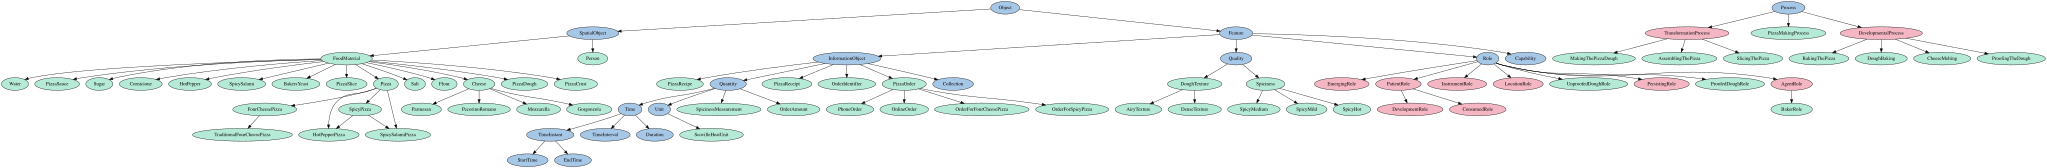

In [8]:
pizza.save(file="dist/pizza-04.owl", format="rdfxml")
print("Saved pizza-04.owl")
display(get_color_tree([sulo, pro, pizza]))

---

### YOUR TURN 1 — `NutritionalLabel`

Food products carry nutritional labels — information objects that describe the properties of the food they are attached to.

- Define `NutritionalLabel` as a subclass of `sulo:InformationObject` that `refersTo` some `FoodMaterial`
- Define `CalorieCount` as a subclass of `sulo:Quantity`
- Create a `NutritionalLabel` individual for `PizzaSlice`: attach a `CalorieCount` individual to it via `hasFeature`, and set the calorie value via `hasValue`
- Run the reasoner and verify consistency

In [9]:
# YOUR TURN 1 — your code here


---

## Summary

In this notebook we introduced `sulo:InformationObject` as a second top-level kind alongside `sulo:SpatialObject`, and modelled the information artefacts that accompany the pizza-making pipeline.

### What we built

**Information entity classes**

| Class | Parent | Role |
|---|---|---|
| `PizzaOrder` | `sulo:InformationObject` | encodes a customer request |
| `OnlineOrder` | `PizzaOrder` | order placed via an online platform |
| `PhoneOrder` | `PizzaOrder` | order placed by telephone |
| `PizzaReceipt` | `sulo:InformationObject` | records a completed transaction |
| `OrderIdentifier` | `sulo:InformationObject` | carries a string order ID via `hasValue` |
| `OrderAmount` | `sulo:Quantity` | carries a monetary value via `hasValue` |
| `PizzaMakingProcess` | `sulo:Process` | the full pipeline with ordered sub-process parts |
| `PizzaRecipe` | `sulo:InformationObject` | defined as `refersTo some PizzaMakingProcess` |

**Defined classes**

| Class | Definition |
|---|---|
| `OrderForFourCheesePizza` | `PizzaOrder and refersTo some FourCheesePizza` |
| `OrderForSpicyPizza` | `PizzaOrder and refersTo some SpicyPizza` |
| `PizzaRecipe` | `InformationObject and refersTo some PizzaMakingProcess` |

### Key concepts

**`InformationObject` vs `SpatialObject`.** A spatial object occupies space and has physical properties; an information object carries content about something else. A receipt and the pizza it describes are ontologically distinct kinds of entity.

**`refersTo` as the bridge.** The `sulo:refersTo` property links an information object to the entity it is about. This enables defined classes whose membership is determined by what the information object describes, not by its own intrinsic properties.

**Named individuals and the OWA.** OWL does not assume distinct names refer to distinct individuals. `AllDifferent` closes that gap for a known set of individuals; `owl:sameAs` asserts identity across names. Counting via `C.instances()` gives a lower bound on distinct individuals — for the authoritative count over inferred classifications, use a SPARQL `COUNT` query against a reasoner-backed triplestore.

**Recipe to realization.** A `PizzaRecipe` is defined by what it refers to: a `PizzaMakingProcess` whose sub-processes are ordered by `precedes`. Linking a plain `InformationObject` individual to such a process individual is enough for the reasoner to classify it as a `PizzaRecipe`.

### What comes next

Notebook 05 covers **time** — representing temporal intervals, durations, and process anchoring using SULO's `Time` hierarchy and `atTime`.